# Air Quality Dataset — Cleaning, Transformation & Data Modeling

**Dataset:** `team_1.parquet` — Delhi air-quality + meteorological monitoring data
**Rows / Columns (raw):** 3,495,959 rows × 22 columns
**Coverage:** 6 monitoring stations, 13 pollutants, Jan 2024 – Dec 2025, 15-minute frequency

This notebook performs **data cleaning, validation, transformation, and data modeling only** —
no predictive machine learning is built here, per the project scope. The pipeline:

1. Load & profile the raw data
2. Missing value analysis & treatment
3. Duplicate & consistency checks
4. Memory/dtype optimization
5. Outlier detection & treatment
6. Feature engineering (date features + AQI sub-index)
7. Long → wide transformation
8. Star-schema data model (dimension + fact tables)
9. Load into a SQLite database
10. Exploratory data analysis
11. Export cleaned datasets (consumed later by the companion Streamlit app)

> All steps below were run against your actual `team_1.parquet` file — the numbers, shapes, and
> charts you see are real outputs, not illustrative placeholders.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import warnings
import gc
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RAW_PATH = '/mnt/user-data/uploads/team_1.parquet'   # change this path if running elsewhere
OUT_DIR  = '.'                                        # cleaned files + db are written here
DB_PATH  = f'{OUT_DIR}/air_quality.db'

## 2. Loading the Dataset

`pyarrow` is used as the parquet engine via `pandas.read_parquet` (fast, columnar, preserves
dtypes including timezone-aware datetimes).

In [2]:
df = pd.read_parquet(RAW_PATH)
RAW_SHAPE = df.shape
print('Shape:', df.shape)
df.head()

Shape: (3495959, 22)


,station_id,state,city,station_name,timestamp,datetime,at_c,rh_percent,ws_m_s,wd_deg,rf_mm,tot_rf_mm,sr_w_mt2,bp_mmhg,vws_m_s,pollutant,value,station,year,month,day,hour
0,site_5024,Delhi,Delhi,"Alipur, Delhi - DPCC",2024-01-01T00:00:00.000000+0000,2024-01-01 00:00:00+00:00,8.2,76.0,NaN,72.9,0.0,0.0,3.8,973.7,NaN,benzene,2.10,"Alipur, Delhi - DPCC",2024,1,1,0
1,site_301,Delhi,Delhi,"Anand Vihar, Delhi - DPCC",2024-01-01T00:00:00.000000+0000,2024-01-01 00:00:00+00:00,11.5,80.0,0.3,44.0,NaN,0.0,5.0,742.0,NaN,no2,45.90,"Anand Vihar, Delhi - DPCC",2024,1,1,0
2,site_1420,Delhi,Delhi,"Ashok Vihar, Delhi - DPCC",2024-01-01T00:00:00.000000+0000,2024-01-01 00:00:00+00:00,10.9,83.9,1.0,57.7,0.0,0.0,5.4,983.1,NaN,co,0.90,"Ashok Vihar, Delhi - DPCC",2024,1,1,0
3,site_301,Delhi,Delhi,"Anand Vihar, Delhi - DPCC",2024-01-01T00:00:00.000000+0000,2024-01-01 00:00:00+00:00,11.5,80.0,0.3,44.0,NaN,0.0,5.0,742.0,NaN,nh3,18.80,"Anand Vihar, Delhi - DPCC",2024,1,1,0
4,site_301,Delhi,Delhi,"Anand Vihar, Delhi - DPCC",2024-01-01T00:00:00.000000+0000,2024-01-01 00:00:00+00:00,11.5,80.0,0.3,44.0,NaN,0.0,5.0,742.0,NaN,co,1.57,"Anand Vihar, Delhi - DPCC",2024,1,1,0


## 3. First Look at the Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3495959 entries, 0 to 3495958
Data columns (total 22 columns):
 #   Column        Dtype              
---  ------        -----              
 0   station_id    str                
 1   state         str                
 2   city          str                
 3   station_name  str                
 4   timestamp     str                
 5   datetime      datetime64[us, UTC]
 6   at_c          float64            
 7   rh_percent    float64            
 8   ws_m_s        float64            
 9   wd_deg        float64            
 10  rf_mm         float64            
 11  tot_rf_mm     float64            
 12  sr_w_mt2      float64            
 13  bp_mmhg       float64            
 14  vws_m_s       float64            
 15  pollutant     str                
 16  value         float64            
 17  station       str                
 18  year          int32              
 19  month         int32              
 20  day           int32              
 

### 3a. Numeric Summary Statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
at_c,2655392.0,25.752533,8.318434,0.8,18.7,28.40,32.0,48.40
rh_percent,2655904.0,63.628111,18.639103,11.0,48.0,65.00,80.0,97.00
ws_m_s,1872472.0,1.156522,1.227988,0.1,0.3,1.00,1.4,46.50
wd_deg,2631704.0,151.666807,88.160352,1.0,61.0,143.00,234.0,359.00
rf_mm,2063747.0,0.033591,0.594391,0.0,0.0,0.00,0.0,50.00
tot_rf_mm,3495959.0,0.019829,0.456984,0.0,0.0,0.00,0.0,50.00
sr_w_mt2,2654290.0,124.799195,169.335347,1.0,5.0,11.00,246.0,957.00
bp_mmhg,2655607.0,930.274829,102.883372,719.0,975.0,982.00,988.0,1000.00
vws_m_s,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,3495959.0,53.509529,95.131841,0.0,3.1,17.99,55.3,999.09


### 3b. Categorical / Identifier Columns

How many unique stations, pollutants, etc. are actually in the data.

In [5]:
cat_cols = ['station_id', 'state', 'city', 'station_name', 'pollutant', 'station']
for c in cat_cols:
    print(f'{c:15s} -> {df[c].nunique()} unique values')

print()
print('Pollutants present:')
print(df['pollutant'].value_counts())

station_id      -> 6 unique values
state           -> 1 unique values
city            -> 1 unique values
station_name    -> 6 unique values
pollutant       -> 13 unique values


station         -> 6 unique values

Pollutants present:
pollutant
pm10           399011
no2            396448
pm25           395771
ozone          388529
co             387853
no             377553
benzene        267679
toluene        267223
nh3            260476
so2            248928
xylene          40713
eth_benzene     34997
mp_xylene       30778
Name: count, dtype: int64


### 3c. Station identifier mapping

`station_id`, `station`, and `station_name` look redundant — confirming the 1:1 mapping
before deciding what to keep.

In [6]:
print(df[['station_id', 'station', 'station_name']].drop_duplicates().to_string(index=False))

station_id                      station                 station_name
 site_5024         Alipur, Delhi - DPCC         Alipur, Delhi - DPCC
  site_301    Anand Vihar, Delhi - DPCC    Anand Vihar, Delhi - DPCC
 site_1420    Ashok Vihar, Delhi - DPCC    Ashok Vihar, Delhi - DPCC
  site_108       Aya Nagar, Delhi - IMD       Aya Nagar, Delhi - IMD
 site_1560         Bawana, Delhi - DPCC         Bawana, Delhi - DPCC
  site_104 Burari Crossing, Delhi - IMD Burari Crossing, Delhi - IMD


## 4. Missing Value Analysis

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_report

,missing_count,missing_pct
vws_m_s,3495959,100.00
ws_m_s,1623487,46.44
rf_mm,1432212,40.97
wd_deg,864255,24.72
sr_w_mt2,841669,24.08
at_c,840567,24.04
bp_mmhg,840352,24.04
rh_percent,840055,24.03


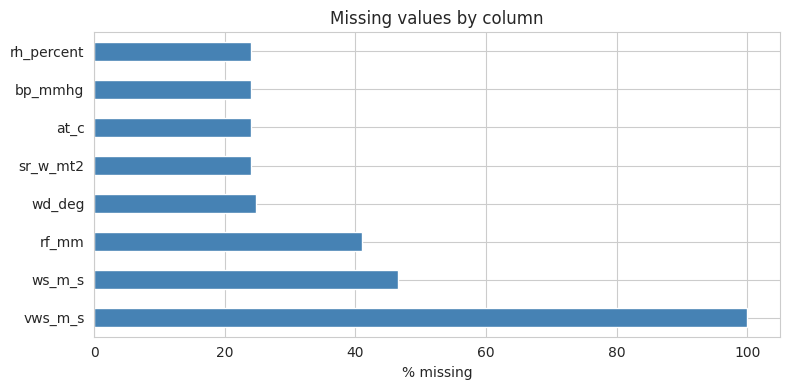

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_report['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
plt.tight_layout()
plt.show()

### 4a. Investigating *why* meteorological columns are missing

`vws_m_s` is 100% missing (dead column). The other weather columns (`at_c`, `rh_percent`,
`ws_m_s`, `wd_deg`, `rf_mm`, `sr_w_mt2`, `bp_mmhg`) sit around 24–46% missing — let's check
whether that's random or tied to specific stations.

In [9]:
missing_by_station = df[df['at_c'].isna()]['station'].value_counts()
print(missing_by_station)
print()
print('Rows per station overall:')
print(df['station'].value_counts())

station
Aya Nagar, Delhi - IMD          449467
Burari Crossing, Delhi - IMD    383476
Alipur, Delhi - DPCC              2871
Anand Vihar, Delhi - DPCC         2714
Bawana, Delhi - DPCC              1133
Ashok Vihar, Delhi - DPCC          906
Name: count, dtype: int64

Rows per station overall:
station
Alipur, Delhi - DPCC            727031
Bawana, Delhi - DPCC            672407
Ashok Vihar, Delhi - DPCC       668756
Anand Vihar, Delhi - DPCC       594822
Aya Nagar, Delhi - IMD          449467
Burari Crossing, Delhi - IMD    383476
Name: count, dtype: int64


**Finding:** the two **IMD** stations (*Aya Nagar* and *Burari Crossing*) account for almost
all the missing weather readings — these are pollutant-only monitoring sites with no
meteorological sensors installed, not a data-quality bug. The four **DPCC** stations only have
small, short sensor-outage gaps. This distinction drives the imputation strategy in Section 9:
we interpolate the short DPCC outages, but we deliberately leave the IMD stations' weather
fields as `NaN` rather than fabricate values for a sensor that was never there.

## 5. Duplicate Records Check

In [10]:
print('Full-row duplicates:', df.duplicated().sum())
print('Duplicates on natural key (station_id, datetime, pollutant):',
      df.duplicated(subset=['station_id', 'datetime', 'pollutant']).sum())

Full-row duplicates: 0


Duplicates on natural key (station_id, datetime, pollutant): 0


No duplicates on either check — each (station, timestamp, pollutant) combination is unique,
confirming this natural key for the fact table built in Section 15.

## 6. Data Validation / Sanity Checks

Domain range checks and cross-column consistency checks before we trust the data.

In [11]:
checks = {
    'rh_percent in [0, 100]':      df['rh_percent'].dropna().between(0, 100).all(),
    'wd_deg in [0, 360]':          df['wd_deg'].dropna().between(0, 360).all(),
    'value is non-negative':       (df['value'].dropna() >= 0).all(),
}

date_mismatch = (
    (df['year']  != df['datetime'].dt.year)  |
    (df['month'] != df['datetime'].dt.month) |
    (df['day']   != df['datetime'].dt.day)   |
    (df['hour']  != df['datetime'].dt.hour)
).sum()
checks['year/month/day/hour matches datetime'] = (date_mismatch == 0)

for name, passed in checks.items():
    print(f'{"PASS" if passed else "FAIL":5s} | {name}')

PASS  | rh_percent in [0, 100]
PASS  | wd_deg in [0, 360]
PASS  | value is non-negative
PASS  | year/month/day/hour matches datetime


## 7. Dropping Redundant / Empty Columns

- `vws_m_s` — 100% missing, no information content
- `timestamp` — string duplicate of the already-parsed `datetime` column

In [12]:
print('Before:', df.shape)
df = df.drop(columns=['vws_m_s', 'timestamp'])
print('After: ', df.shape)

Before: (3495959, 22)
After:  (3495959, 20)


## 8. Memory Optimization (dtype downcasting)

Converting identifier/text columns to `category` and downcasting numeric columns cuts memory
use substantially with zero loss of information for this dataset's value ranges.

In [13]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2

cat_cols = ['station_id', 'state', 'city', 'station_name', 'pollutant', 'station']
for c in cat_cols:
    df[c] = df[c].astype('category')

float_cols = ['at_c', 'rh_percent', 'ws_m_s', 'wd_deg', 'rf_mm', 'tot_rf_mm',
              'sr_w_mt2', 'bp_mmhg', 'value']
for c in float_cols:
    df[c] = df[c].astype('float32')

for c in ['year', 'month', 'day', 'hour']:
    df[c] = df[c].astype('int16')

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memory before: {mem_before:.1f} MB')
print(f'Memory after:  {mem_after:.1f} MB')
print(f'Reduction:     {100*(1 - mem_after/mem_before):.1f}%')

Memory before: 708.4 MB
Memory after:  193.4 MB
Reduction:     72.7%


## 9. Treating Missing Meteorological Data

Each station's weather readings are a genuine time series, so missing values are filled with
**time-ordered linear interpolation, computed independently per station** (never across station
boundaries). As established in Section 4a, the two IMD stations have no sensor at all for these
fields — interpolation cannot and should not invent values there, so they correctly remain
`NaN` after this step.

In [14]:
met_cols = ['at_c', 'rh_percent', 'ws_m_s', 'wd_deg', 'rf_mm', 'sr_w_mt2', 'bp_mmhg']
before_missing = df[met_cols].isna().sum()

df = df.sort_values(['station_id', 'datetime'])
df[met_cols] = (
    df.groupby('station_id', group_keys=False, observed=True)[met_cols]
      .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
)

after_missing = df[met_cols].isna().sum()
pd.DataFrame({'missing_before': before_missing, 'missing_after': after_missing})

,missing_before,missing_after
at_c,840567,832943
rh_percent,840055,832943
ws_m_s,1623487,1559974
wd_deg,864255,832943
rf_mm,1432212,1427765
sr_w_mt2,841669,832943
bp_mmhg,840352,832943


## 10. Outlier Detection (IQR method, per pollutant)

Pollutant scales differ hugely (CO ~0–50 mg/m³ vs PM10 ~0–1000 µg/m³), so outlier bounds are
computed **separately for each pollutant** using the classic 1.5×IQR rule.

In [15]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

bounds = df.groupby('pollutant', observed=True)['value'].apply(iqr_bounds).to_dict()
pollutant_str = df['pollutant'].astype(str)

df['value_lo'] = pollutant_str.map(lambda p: bounds[p][0]).astype('float32')
df['value_hi'] = pollutant_str.map(lambda p: bounds[p][1]).astype('float32')
df['is_outlier'] = (df['value'] < df['value_lo']) | (df['value'] > df['value_hi'])

print(f"Flagged {df['is_outlier'].sum():,} outliers out of {len(df):,} rows "
      f"({100*df['is_outlier'].mean():.2f}%)")
df.groupby('pollutant', observed=True)['is_outlier'].mean().mul(100).round(2).sort_values(ascending=False)

Flagged 228,905 outliers out of 3,495,959 rows (6.55%)


pollutant
xylene         13.62
no             12.32
mp_xylene      11.40
toluene        10.36
eth_benzene     9.98
benzene         8.33
ozone           6.39
co              5.88
pm25            5.38
no2             4.92
so2             4.83
pm10            3.30
nh3             2.40
Name: is_outlier, dtype: float64

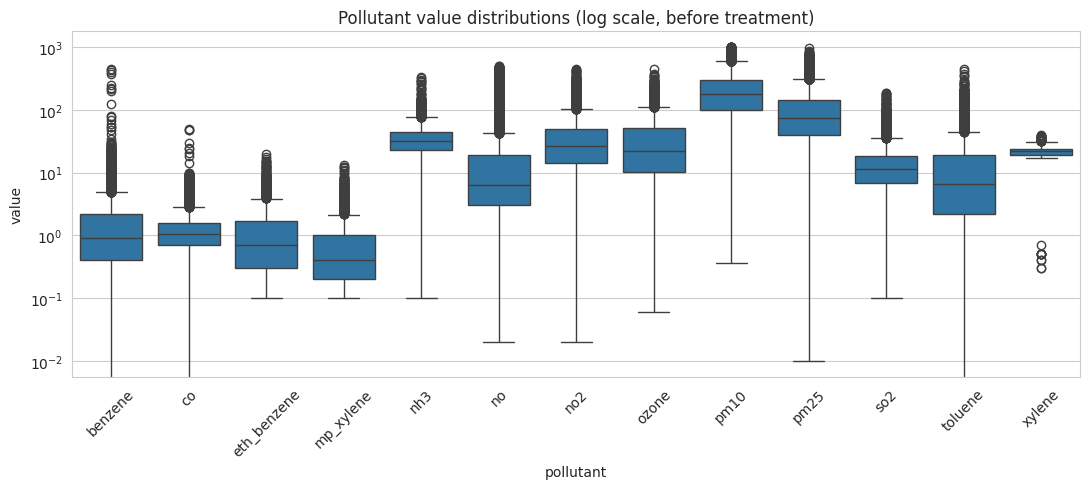

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
sample = df.sample(min(200_000, len(df)), random_state=42)
sns.boxplot(data=sample, x='pollutant', y='value', ax=ax)
ax.set_yscale('log')
ax.set_title('Pollutant value distributions (log scale, before treatment)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Outlier Treatment (Winsorization)

Rather than deleting flagged rows (which would create gaps in the time series), extreme values
are **capped (winsorized)** at the IQR bounds into a new `value_clean` column. The original
`value` and the `is_outlier` flag are preserved, so nothing is silently lost.

In [17]:
df['value_clean'] = df['value'].clip(lower=df['value_lo'].clip(lower=0), upper=df['value_hi'])
df = df.drop(columns=['value_lo', 'value_hi'])

comparison = df.groupby('pollutant', observed=True)[['value', 'value_clean']].agg(['mean', 'max'])
comparison

value             value_clean            
                   mean         max        mean         max
pollutant                                                  
benzene        1.966453  481.700012    1.504938    4.900000
co             1.308683   49.970001    1.223518    2.895000
eth_benzene    1.503923   24.600000    1.191974    3.800000
mp_xylene      0.946312   14.800000    0.715527    2.200000
nh3           35.063438  349.899994   34.543720   77.449997
no            22.059196  499.799988   13.462344   43.770000
no2           37.617065  499.399994   35.783813  103.959999
ozone         37.594055  497.119995   35.407188  113.200005
pm10         217.937775  999.090027  213.804214  583.500000
pm25         108.767151  998.000000  102.977753  306.500000
so2           14.738349  200.000000   13.848524   36.550003
toluene       16.778549  472.600006   12.890569   43.849998
xylene        19.926399   62.180000   21.415785   30.859999

## 12. Feature Engineering — Date/Time Features

In [18]:
df['day_of_week'] = df['datetime'].dt.dayofweek.astype('int8')
df['is_weekend'] = df['day_of_week'].isin([5, 6])

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['season'] = df['month'].map(season_map).astype('category')

df[['datetime', 'day_of_week', 'is_weekend', 'season']].head()

,datetime,day_of_week,is_weekend,season
27,2024-01-01 00:00:00+00:00,0,False,Winter
28,2024-01-01 00:00:00+00:00,0,False,Winter
29,2024-01-01 00:00:00+00:00,0,False,Winter
30,2024-01-01 00:00:00+00:00,0,False,Winter
31,2024-01-01 00:00:00+00:00,0,False,Winter


## 13. Feature Engineering — AQI Sub-Index

Each pollutant's raw concentration is converted into a 0–500 **AQI sub-index** using the
piecewise-linear breakpoint formula from CPCB's National AQI methodology:

$$I_p = \frac{I_{Hi} - I_{Lo}}{B_{Hi} - B_{Lo}} (C_p - B_{Lo}) + I_{Lo}$$

> **Disclaimer:** the breakpoint table below is the widely-published CPCB (2014) approximation,
> reproduced for *educational/EDA purposes*. If this number is ever used for a real health
> advisory or compliance decision, cross-check it against CPCB's official current document —
> this is a derived descriptive metric, not a certified calculation.

In [19]:
BREAKPOINTS = {
    'pm25':  [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,500,401,500)],
    'pm10':  [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(431,1000,401,500)],
    'no2':   [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,1000,401,500)],
    'so2':   [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,2000,401,500)],
    'co':    [(0,1.0,0,50),(1.1,2.0,51,100),(2.1,10,101,200),(10.1,17,201,300),(17.1,34,301,400),(34.1,50,401,500)],
    'ozone': [(0,50,0,50),(51,100,51,100),(101,168,101,200),(169,208,201,300),(209,748,301,400),(749,1000,401,500)],
    'nh3':   [(0,200,0,50),(201,400,51,100),(401,800,101,200),(801,1200,201,300),(1201,1800,301,400),(1801,2000,401,500)],
}

def sub_index(pollutant, c):
    if pd.isna(c) or pollutant not in BREAKPOINTS:
        return np.nan
    for clo, chi, ilo, ihi in BREAKPOINTS[pollutant]:
        if clo <= c <= chi:
            return ((ihi - ilo) / (chi - clo)) * (c - clo) + ilo
    last = BREAKPOINTS[pollutant][-1]
    return last[3] if c > last[1] else last[2]

def aqi_category(i):
    if pd.isna(i): return np.nan
    if i <= 50:  return 'Good'
    if i <= 100: return 'Satisfactory'
    if i <= 200: return 'Moderate'
    if i <= 300: return 'Poor'
    if i <= 400: return 'Very Poor'
    return 'Severe'

pollutant_str = df['pollutant'].astype(str)
df['aqi_sub_index'] = np.array(
    [sub_index(p, c) for p, c in zip(pollutant_str, df['value_clean'])], dtype='float32'
)
df['aqi_category'] = df['aqi_sub_index'].apply(aqi_category).astype('category')

df[['pollutant', 'value_clean', 'aqi_sub_index', 'aqi_category']].dropna().sample(8, random_state=1)

,pollutant,value_clean,aqi_sub_index,aqi_category
912906,pm10,46.000000,46.000000,Good
688360,ozone,113.200005,119.026871,Moderate
3360355,no2,15.200000,19.000000,Good
2798812,pm10,95.000000,95.000000,Satisfactory
399665,nh3,28.799999,7.200000,Good
650727,ozone,5.000000,5.000000,Good
1172085,pm10,262.000000,212.000000,Poor
2626911,ozone,6.630000,6.630000,Good


## 14. Data Transformation — Long → Wide Reshape

Right now each row is one *(station, timestamp, pollutant)* reading, with the weather columns
repeated across every pollutant for the same timestamp. For analysis it's far more useful to
have **one row per station + timestamp**, with each pollutant as its own column.

Pivoting is done on `(station_id, datetime)` only — pivoting directly on the weather columns
would silently drop every row from the two sensor-less IMD stations (their weather values are
`NaN`, and `NaN` keys get dropped from a pivot index).

In [20]:
wide_values = df.pivot_table(index=['station_id', 'datetime'], columns='pollutant',
                              values='value_clean', aggfunc='first', observed=True)
wide_values.columns = [f'{c}_ugm3' if c != 'co' else 'co_mgm3' for c in wide_values.columns]
wide_values = wide_values.reset_index()

meta_cols = ['station_id', 'station', 'station_name', 'state', 'city', 'datetime',
             'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season',
             'at_c', 'rh_percent', 'ws_m_s', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'sr_w_mt2', 'bp_mmhg']
meta = df[meta_cols].drop_duplicates(subset=['station_id', 'datetime'])

wide = meta.merge(wide_values, on=['station_id', 'datetime'], how='left')
print('Wide shape:', wide.shape)
wide.head()

Wide shape: (409427, 34)


,station_id,station,station_name,state,city,datetime,year,month,day,hour,day_of_week,is_weekend,season,at_c,rh_percent,ws_m_s,wd_deg,rf_mm,tot_rf_mm,sr_w_mt2,bp_mmhg,benzene_ugm3,co_mgm3,eth_benzene_ugm3,mp_xylene_ugm3,nh3_ugm3,no_ugm3,no2_ugm3,ozone_ugm3,pm10_ugm3,pm25_ugm3,so2_ugm3,toluene_ugm3,xylene_ugm3
0,site_104,"Burari Crossing, Delhi - IMD","Burari Crossing, Delhi - IMD",Delhi,Delhi,2024-01-01 00:00:00+00:00,2024,1,1,0,0,False,Winter,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.26,NaN,NaN,NaN,11.67,5.14,19.940001,201.089996,120.639999,NaN,NaN,NaN
1,site_104,"Burari Crossing, Delhi - IMD","Burari Crossing, Delhi - IMD",Delhi,Delhi,2024-01-01 00:15:00+00:00,2024,1,1,0,0,False,Winter,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.11,NaN,NaN,NaN,11.91,5.01,19.570000,200.929993,122.849998,NaN,NaN,NaN
2,site_104,"Burari Crossing, Delhi - IMD","Burari Crossing, Delhi - IMD",Delhi,Delhi,2024-01-01 00:30:00+00:00,2024,1,1,0,0,False,Winter,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.12,NaN,NaN,NaN,11.91,5.14,19.379999,192.669998,114.269997,NaN,NaN,NaN
3,site_104,"Burari Crossing, Delhi - IMD","Burari Crossing, Delhi - IMD",Delhi,Delhi,2024-01-01 00:45:00+00:00,2024,1,1,0,0,False,Winter,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.12,NaN,NaN,NaN,12.30,5.10,21.660000,170.949997,112.070000,NaN,NaN,NaN
4,site_104,"Burari Crossing, Delhi - IMD","Burari Crossing, Delhi - IMD",Delhi,Delhi,2024-01-01 01:00:00+00:00,2024,1,1,1,0,False,Winter,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.12,NaN,NaN,NaN,12.57,5.36,19.500000,159.229996,106.180000,NaN,NaN,NaN


## 15. Building a Star-Schema Data Model

Structuring the cleaned data as **dimension tables** (station, pollutant, time) plus one
**fact table** of readings — a standard data-warehouse pattern that makes the dataset easy to
query, join, and serve efficiently (used directly by the Streamlit app and the SQLite DB below).

In [21]:
# Dimension: station
dim_station = df[['station_id', 'station_name', 'state', 'city']].drop_duplicates().reset_index(drop=True)
dim_station.insert(0, 'station_key', range(1, len(dim_station) + 1))

# Dimension: pollutant
dim_pollutant = pd.DataFrame({'pollutant': sorted(pollutant_str.unique())})
dim_pollutant.insert(0, 'pollutant_key', range(1, len(dim_pollutant) + 1))

# Dimension: time
dim_time = df[['datetime', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season']]\
             .drop_duplicates().reset_index(drop=True)
dim_time.insert(0, 'time_key', range(1, len(dim_time) + 1))

# Surrogate keys are attached via dict-based .map() rather than .merge() — a 3-way merge
# of dimension tables back onto a 3.5M-row fact table briefly creates several full copies of
# the data in memory, which is unnecessary when a simple key lookup does the same job for a fraction
# of the memory.
station_key_map   = dict(zip(dim_station['station_id'].astype(str), dim_station['station_key']))
pollutant_key_map = dict(zip(dim_pollutant['pollutant'], dim_pollutant['pollutant_key']))
time_key_map       = dict(zip(dim_time['datetime'], dim_time['time_key']))

df['station_key']   = df['station_id'].astype(str).map(station_key_map).astype('int32')
df['pollutant_key'] = pollutant_str.map(pollutant_key_map).astype('int32')
df['time_key']       = df['datetime'].map(time_key_map).astype('int32')

print('dim_station    :', dim_station.shape)
print('dim_pollutant   :', dim_pollutant.shape)
print('dim_time        :', dim_time.shape)
dim_station

dim_station    : (6, 5)
dim_pollutant   : (13, 2)
dim_time        : (70176, 9)


,station_key,station_id,station_name,state,city
0,1,site_104,"Burari Crossing, Delhi - IMD",Delhi,Delhi
1,2,site_108,"Aya Nagar, Delhi - IMD",Delhi,Delhi
2,3,site_1420,"Ashok Vihar, Delhi - DPCC",Delhi,Delhi
3,4,site_1560,"Bawana, Delhi - DPCC",Delhi,Delhi
4,5,site_301,"Anand Vihar, Delhi - DPCC",Delhi,Delhi
5,6,site_5024,"Alipur, Delhi - DPCC",Delhi,Delhi


## 16. Loading into a SQLite Database

The star schema is loaded into a local SQLite database — a lightweight, file-based, zero-config
database that the Streamlit app can query directly with SQL. The fact table is built right
before loading and freed immediately after, since a 3.5M-row table held alongside everything
else in `df` is the single biggest consumer of memory in this notebook.

In [22]:
fact_cols = ['station_key', 'pollutant_key', 'time_key', 'value', 'value_clean', 'is_outlier',
             'aqi_sub_index', 'aqi_category', 'at_c', 'rh_percent', 'ws_m_s', 'wd_deg',
             'rf_mm', 'tot_rf_mm', 'sr_w_mt2', 'bp_mmhg']
fact_air_quality = df[fact_cols].copy()
fact_air_quality.insert(0, 'reading_key', range(1, len(fact_air_quality) + 1))
print('fact_air_quality:', fact_air_quality.shape)

conn = sqlite3.connect(DB_PATH)
dim_station.to_sql('dim_station', conn, if_exists='replace', index=False)
dim_pollutant.to_sql('dim_pollutant', conn, if_exists='replace', index=False)
dim_time.to_sql('dim_time', conn, if_exists='replace', index=False)
fact_air_quality.to_sql('fact_air_quality', conn, if_exists='replace', index=False, chunksize=100_000)

conn.execute('CREATE INDEX IF NOT EXISTS idx_fact_station ON fact_air_quality(station_key)')
conn.execute('CREATE INDEX IF NOT EXISTS idx_fact_pollutant ON fact_air_quality(pollutant_key)')
conn.execute('CREATE INDEX IF NOT EXISTS idx_fact_time ON fact_air_quality(time_key)')
conn.commit()
print('Tables written to', DB_PATH)

fact_air_quality: (3495959, 17)


Tables written to ./air_quality.db


In [23]:
# Sanity-check the schema with a real join query
check = pd.read_sql('''
    SELECT s.station_name, p.pollutant, ROUND(AVG(f.value_clean), 2) AS avg_value
    FROM fact_air_quality f
    JOIN dim_station   s ON f.station_key = s.station_key
    JOIN dim_pollutant  p ON f.pollutant_key = p.pollutant_key
    WHERE p.pollutant IN ('pm25', 'pm10', 'no2')
    GROUP BY s.station_name, p.pollutant
    ORDER BY s.station_name, p.pollutant
''', conn)
conn.close()
check

,station_name,pollutant,avg_value
0,"Alipur, Delhi - DPCC",no2,33.63
1,"Alipur, Delhi - DPCC",pm10,203.37
2,"Alipur, Delhi - DPCC",pm25,97.22
3,"Anand Vihar, Delhi - DPCC",no2,63.78
4,"Anand Vihar, Delhi - DPCC",pm10,275.05
5,"Anand Vihar, Delhi - DPCC",pm25,121.66
6,"Ashok Vihar, Delhi - DPCC",no2,44.97
7,"Ashok Vihar, Delhi - DPCC",pm10,220.39
8,"Ashok Vihar, Delhi - DPCC",pm25,103.35
9,"Aya Nagar, Delhi - IMD",no2,27.21


`fact_air_quality` has done its job (loaded into SQLite) and isn't needed again in this
notebook — freeing it now keeps memory available for the EDA and export steps below.

In [24]:
del fact_air_quality
gc.collect()
print('Freed fact_air_quality from memory.')

Freed fact_air_quality from memory.


## 17. Exploratory Data Analysis

### 17a. Monthly PM2.5 / PM10 trend

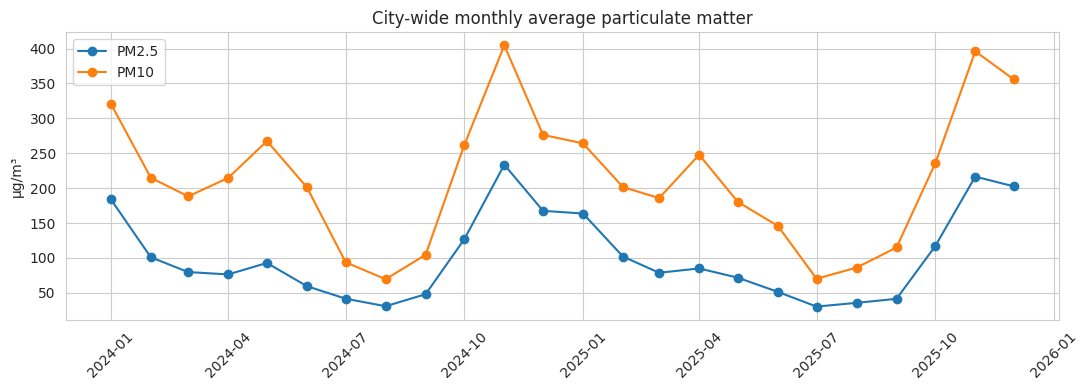

In [25]:
monthly = wide.groupby(['year', 'month'])[['pm25_ugm3', 'pm10_ugm3']].mean().reset_index()
monthly['period'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly['period'], monthly['pm25_ugm3'], marker='o', label='PM2.5')
ax.plot(monthly['period'], monthly['pm10_ugm3'], marker='o', label='PM10')
ax.set_ylabel('µg/m³'); ax.set_title('City-wide monthly average particulate matter')
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 17b. Station comparison (average PM2.5)

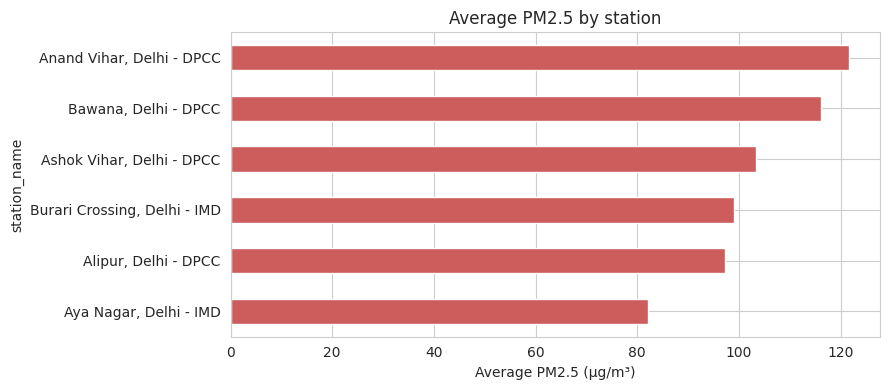

In [26]:
station_avg = wide.groupby('station_name')['pm25_ugm3'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
station_avg.plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('Average PM2.5 (µg/m³)'); ax.set_title('Average PM2.5 by station')
plt.tight_layout(); plt.show()

### 17c. Weekday vs weekend pollution levels

In [27]:
weekend_cmp = wide.groupby('is_weekend')[['pm25_ugm3', 'pm10_ugm3', 'no2_ugm3']].mean()
weekend_cmp.index = weekend_cmp.index.map({True: 'Weekend', False: 'Weekday'})
weekend_cmp

,pm25_ugm3,pm10_ugm3,no2_ugm3
is_weekend,,,
Weekday,102.665573,213.964005,35.847790
Weekend,103.758835,213.405273,35.623001


### 17d. Weather vs pollutant correlation

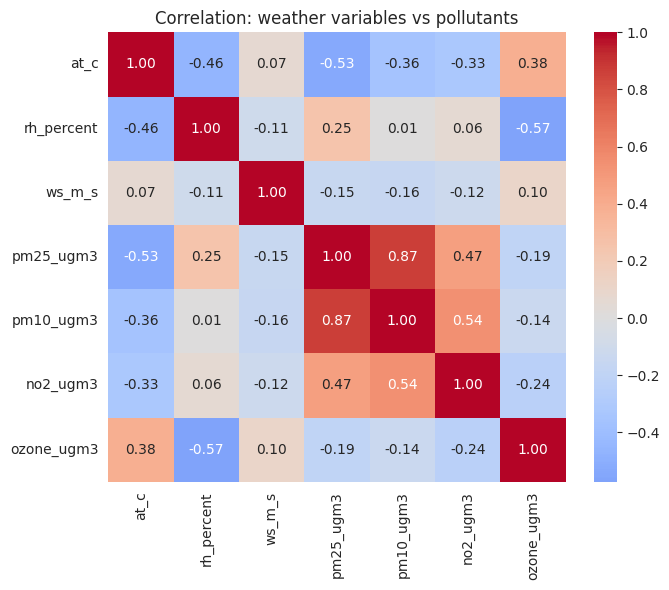

In [28]:
corr_cols = ['at_c', 'rh_percent', 'ws_m_s', 'pm25_ugm3', 'pm10_ugm3', 'no2_ugm3', 'ozone_ugm3']
corr = wide[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation: weather variables vs pollutants')
plt.tight_layout(); plt.show()

### 17e. AQI category distribution (PM2.5)

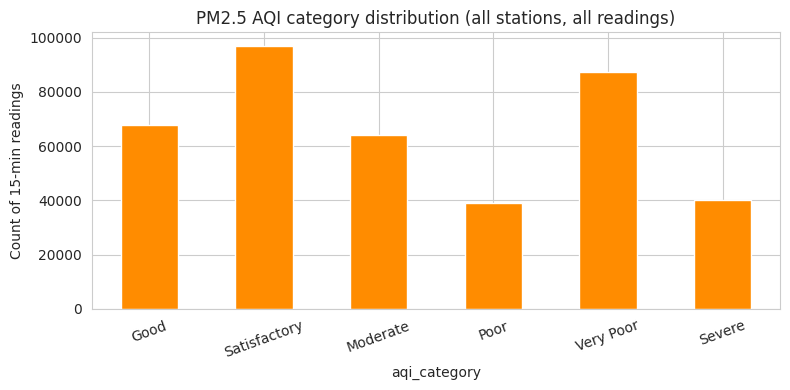

In [29]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
pm25_cat = df[df['pollutant'].astype(str) == 'pm25']['aqi_category'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
pm25_cat.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('PM2.5 AQI category distribution (all stations, all readings)')
ax.set_ylabel('Count of 15-min readings')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 18. Exporting Cleaned Data

Both the long (tidy/fact-style) and wide (one row per station+timestamp) cleaned datasets are
exported as parquet — these are what the companion Streamlit app reads.

In [30]:
long_path = f'{OUT_DIR}/cleaned_long.parquet'
wide_path = f'{OUT_DIR}/cleaned_wide.parquet'

df.to_parquet(long_path, index=False)
wide.to_parquet(wide_path, index=False)

import os
for p in [long_path, wide_path, DB_PATH]:
    print(f'{p:35s} {os.path.getsize(p)/1024**2:7.1f} MB')

./cleaned_long.parquet                 30.6 MB
./cleaned_wide.parquet                  7.4 MB
./air_quality.db                      341.5 MB


A small `cleaning_summary.json` is also saved — this lets the Streamlit app show the
cleaning report instantly without re-loading and re-aggregating the full 3.5M-row dataset
every time the app starts.

In [31]:
import json

outlier_by_pollutant = (
    df.groupby('pollutant', observed=True)['is_outlier'].mean().mul(100).round(2).to_dict()
)
outlier_by_pollutant = {str(k): v for k, v in outlier_by_pollutant.items()}

summary = {
    'raw_shape': list(RAW_SHAPE),
    'cleaned_long_shape': list(df.shape),
    'cleaned_wide_shape': list(wide.shape),
    'dropped_columns': ['vws_m_s (100% missing)', 'timestamp (redundant with datetime)'],
    'date_range': [str(df['datetime'].min()), str(df['datetime'].max())],
    'stations': sorted(df['station_name'].astype(str).unique().tolist()),
    'pollutants': sorted(pollutant_str.unique().tolist()),
    'missing_before': {k: int(v) for k, v in before_missing.items()},
    'missing_after': {k: int(v) for k, v in after_missing.items()},
    'outlier_pct_by_pollutant': outlier_by_pollutant,
    'total_outliers_flagged': int(df['is_outlier'].sum()),
    'stations_without_weather_sensors': ['Aya Nagar, Delhi - IMD', 'Burari Crossing, Delhi - IMD'],
}

with open(f'{OUT_DIR}/cleaning_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved cleaning_summary.json')
summary

Saved cleaning_summary.json


{'raw_shape': [3495959, 22],
 'cleaned_long_shape': [3495959, 30],
 'cleaned_wide_shape': [409427, 34],
 'dropped_columns': ['vws_m_s (100% missing)',
  'timestamp (redundant with datetime)'],
 'date_range': ['2024-01-01 00:00:00+00:00', '2025-12-31 23:45:00+00:00'],
 'stations': ['Alipur, Delhi - DPCC',
  'Anand Vihar, Delhi - DPCC',
  'Ashok Vihar, Delhi - DPCC',
  'Aya Nagar, Delhi - IMD',
  'Bawana, Delhi - DPCC',
  'Burari Crossing, Delhi - IMD'],
 'pollutants': ['benzene',
  'co',
  'eth_benzene',
  'mp_xylene',
  'nh3',
  'no',
  'no2',
  'ozone',
  'pm10',
  'pm25',
  'so2',
  'toluene',
  'xylene'],
 'missing_before': {'at_c': 840567,
  'rh_percent': 840055,
  'ws_m_s': 1623487,
  'wd_deg': 864255,
  'rf_mm': 1432212,
  'sr_w_mt2': 841669,
  'bp_mmhg': 840352},
 'missing_after': {'at_c': 832943,
  'rh_percent': 832943,
  'ws_m_s': 1559974,
  'wd_deg': 832943,
  'rf_mm': 1427765,
  'sr_w_mt2': 832943,
  'bp_mmhg': 832943},
 'outlier_pct_by_pollutant': {'benzene': 8.33,
  'co': 

## 19. Summary & Notes

**What was done:**
- Dropped 1 dead column (`vws_m_s`, 100% missing) and 1 redundant column (`timestamp`)
- Validated value ranges, date consistency, and the natural key — no violations found
- Interpolated short meteorological sensor outages **per station, in time order** (deliberately
  left the two sensor-less IMD stations' weather fields as `NaN` rather than fabricate values)
- Flagged and winsorized outliers **per pollutant** (concentration scales vary too much for a
  single global threshold)
- Engineered date features and a CPCB-style AQI sub-index/category per reading
- Reshaped from long (one row per reading) to wide (one row per station+timestamp)
- Built a star-schema data model (3 dimension tables + 1 fact table) and loaded it into SQLite
- Ran exploratory analysis on trends, station comparisons, and weather/pollutant correlation
- Exported cleaned long & wide parquet files for downstream use

**Known limitations (stated honestly, not glossed over):**
- The AQI breakpoint table is an educational approximation of CPCB's published methodology —
  verify against the official current document before using it for any real decision
- 2 of 6 stations have no meteorological sensor at all; their weather fields are intentionally
  left missing rather than imputed
- Outlier treatment caps (winsorizes) rather than removes — appropriate for keeping the time
  series continuous, but means `value_clean` is not the literal raw sensor reading at the tails

**Next step:** the companion Streamlit app (`streamlit_app.py`) reads `cleaned_wide.parquet`,
`cleaning_summary.json`, and `air_quality.db` to serve an interactive cleaning report + EDA
dashboard.